# DepaRent — Pipeline de Exploración, Procesamiento y Modelado (Semana 06)

Este notebook contiene el análisis exploratorio, la limpieza de datos, la ingeniería de características y el benchmark de modelos para **DepaRent**.

Se procesan y articulan tres fuentes de datos complementarias:
1. **Catálogo de departamentos en alquiler** obtenido mediante web scraping (3,822 anuncios y 43 atributos).
2. **Series históricas del BCRP** con información macroeconómica trimestral de precios de alquiler y venta por distrito (663 registros, periodo 2004–2026).
3. **Red oficial de paraderos de la ATU** para Lima Metropolitana y Callao (3,233 paraderos de transporte público).

A lo largo del flujo se limpian inconsistencias, se recuperan atributos desde texto libre, se construyen métricas espaciales de accesibilidad y se comparan los modelos candidatos para la arquitectura analítica.

## 0. Setup y configuración del entorno

In [1]:
import re
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial import cKDTree

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors, KNeighborsRegressor
from sklearn.metrics import silhouette_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

try:
    from statsmodels.tsa.stattools import adfuller
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print("statsmodels no disponible: instalar con pip install statsmodels")

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (10, 6)


## 1. Carga de datos

In [2]:
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Si se ejecuta en Colab y no existen los archivos, solicita la subida
if IN_COLAB:
    archivos_necesarios = [
        'departamentos_alquiler_lima.csv',
        'dataset_alquileres_trimestre_bcrp.csv',
        'paraderos.csv'
    ]
    if not all(Path(f).exists() for f in archivos_necesarios):
        uploaded = files.upload()

# Búsqueda automática de la ruta de datos (local o Colab)
candidatos_data_dir = [
    Path('.'),
    Path('../../week04/data'),
    Path('DepaMatch/deliveries/week04/data'),
    Path('../data'),
    Path('data')
]

DATA_DIR = next((p for p in candidatos_data_dir if (p / 'departamentos_alquiler_lima.csv').exists()), Path('.'))
PROCESSED_DIR = Path('processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

df_dep_raw = pd.read_csv(DATA_DIR / 'departamentos_alquiler_lima.csv')
df_bcrp_raw = pd.read_csv(DATA_DIR / 'dataset_alquileres_trimestre_bcrp.csv')
df_par_raw = pd.read_csv(DATA_DIR / 'paraderos.csv')

print('Tamano de los 3 datasets cargados')
print(f'''
Departamentos: {df_dep_raw.shape[0]} filas x {df_dep_raw.shape[1]} columnas
BCRP:          {df_bcrp_raw.shape[0]} filas x {df_bcrp_raw.shape[1]} columnas
Paraderos:     {df_par_raw.shape[0]} filas x {df_par_raw.shape[1]} columnas
''')


Tamano de los 3 datasets cargados

Departamentos: 3822 filas x 43 columnas
BCRP:          663 filas x 6 columnas
Paraderos:     3233 filas x 10 columnas



Los tres conjuntos de datos cargados corresponden a las fuentes base del proyecto:

| Dataset | Registros | Columnas | Descripción |
| :--- | :---: | :---: | :--- |
| **Departamentos (Scraping)** | **3,822** | **43** | Anuncios individuales de alquiler en Lima Metropolitana y Callao, incluyendo `medios_banos` y texto de amenidades. |
| **BCRP (Trimestral)** | **663** | **6** | Series trimestrales de PER, precio de venta por m² en USD y alquiler mensual en soles por distrito. |
| **Paraderos (ATU)** | **3,233** | **10** | Inventario oficial de paraderos del sistema de transporte metropolitano (Troncal BRT, Corredores y Transporte Regular). |

## 2. Diagnóstico de nulos en el dataset crudo

In [3]:
null_report = pd.DataFrame({
    "tipo": df_dep_raw.dtypes,
    "nulos": df_dep_raw.isna().sum(),
    "% nulos": (df_dep_raw.isna().mean() * 100).round(2),
}).sort_values("% nulos", ascending=False)

nulos_100 = null_report[null_report["% nulos"] == 100].index.tolist()
print("Columnas con valores nulos:")
print(null_report[null_report["nulos"] > 0].to_string())


Columnas con valores nulos:
                      tipo  nulos  % nulos
parrilla           float64   3822   100.00
vista_al_mar       float64   3822   100.00
deposito           float64   3822   100.00
seguridad_24_7     float64   3822   100.00
coworking          float64   3822   100.00
juegos_infantiles  float64   3822   100.00
areas_verdes       float64   3822   100.00
caracteristicas    float64   3822   100.00
estado_inmueble    float64   3822   100.00
nombre_proyecto    float64   3822   100.00
piso               float64   3822   100.00
pet_friendly       float64   3822   100.00
piscina            float64   3822   100.00
ascensor           float64   3822   100.00
gimnasio           float64   3822   100.00
terraza            float64   3822   100.00
balcon             float64   3822   100.00
medios_banos       float64   2917    76.32
estacionamientos   float64   1750    45.79
cochera            float64   1750    45.79
mantenimiento      float64   1001    26.19
antiguedad         float64

En el archivo crudo existen **17 columnas con 100% de valores nulos**:
`['parrilla', 'vista_al_mar', 'deposito', 'seguridad_24_7', 'coworking', 'juegos_infantiles', 'areas_verdes', 'caracteristicas', 'estado_inmueble', 'nombre_proyecto', 'piso', 'pet_friendly', 'piscina', 'ascensor', 'gimnasio', 'terraza', 'balcon']`

Esta condición responde a la arquitectura del portal inmobiliario de origen, que no provee estas amenidades ni el número de piso en campos JSON estructurados para avisos de alquiler individuales. Para no perder esta información, en la siguiente sección se recuperan mediante expresiones regulares sobre el campo de texto libre `texto_amenidades_crudo`.

## 3. Recuperación de información desde texto libre

In [4]:
df_dep = df_dep_raw.copy()
if "texto_amenidades_crudo" not in df_dep.columns:
    df_dep["texto_amenidades_crudo"] = (
        df_dep["titulo"].fillna("") + " | " +
        df_dep["descripcion"].fillna("") + " | " +
        df_dep["caracteristicas"].fillna("")
    )

corpus = df_dep["texto_amenidades_crudo"].fillna("").str.lower().str.replace("º", "").str.replace("°", "")

# 1. Piso
pat_piso = r"(?:piso|nivel)\s*(\d{1,2})|(\d{1,2})\s*(?:er|do|ro|to|mo|vo|no)?\.?\s*piso"
ext_piso = corpus.str.extract(pat_piso)
piso_rec = ext_piso[0].fillna(ext_piso[1]).astype(float)
piso_valid = piso_rec.where((piso_rec >= 1) & (piso_rec <= 45))
piso_antes = df_dep["piso"].isna().sum()
df_dep["piso"] = df_dep["piso"].fillna(piso_valid)
piso_recuperados = piso_antes - df_dep["piso"].isna().sum()

# 2. Antigüedad (años o estreno)
pat_ant = r"(\d{1,2})\s*a[nñ]os?\s*(?:de\s*)?antig[uü]edad"
ext_ant = corpus.str.extract(pat_ant)[0].astype(float)
es_estreno = corpus.str.contains(r"\b(?:estreno|a estrenar|de estreno)\b", regex=True)
ext_ant = ext_ant.fillna(es_estreno.map({True: 0.0}))
ant_antes = df_dep["antiguedad"].isna().sum()
df_dep["antiguedad"] = df_dep["antiguedad"].fillna(ext_ant)
ant_recuperados = ant_antes - df_dep["antiguedad"].isna().sum()

# 3. Estacionamientos / Cocheras
pat_est = r"(\d{1,2})\s*(?:cocheras?|estacionamientos?|garajes?|parqueos?)"
ext_est = corpus.str.extract(pat_est)[0].astype(float)
tiene_cochera_txt = corpus.str.contains(r"\b(?:con cochera|incluye cochera|1 cochera|cochera techada|cochera incluida)\b", regex=True)
ext_est = ext_est.fillna(tiene_cochera_txt.map({True: 1.0}))
est_antes = df_dep["estacionamientos"].isna().sum()
df_dep["estacionamientos"] = df_dep["estacionamientos"].fillna(ext_est)
est_recuperados = est_antes - df_dep["estacionamientos"].isna().sum()

# 4. Mantenimiento
pat_mant = r"(?:mantenimiento|mant\.?|cuota)\s*(?:aprox\.?|es\s*de|de)?\s*(?:s\/?\.?|soles|\$)?\s*(\d{2,4})"
ext_mant = corpus.str.extract(pat_mant)[0].astype(float)
valid_mant = ext_mant.where((ext_mant >= 50) & (ext_mant <= 2500))
mant_antes = df_dep["mantenimiento"].isna().sum()
df_dep["mantenimiento"] = df_dep["mantenimiento"].fillna(valid_mant)
mant_recuperados = mant_antes - df_dep["mantenimiento"].isna().sum()

resumen_recuperacion = pd.DataFrame([
    {"Variable": "piso", "Recuperados": piso_recuperados, "% Recuperado": round(piso_recuperados/len(df_dep)*100, 2), "Nulos Restantes": df_dep["piso"].isna().sum()},
    {"Variable": "antiguedad", "Recuperados": ant_recuperados, "% Recuperado": round(ant_recuperados/len(df_dep)*100, 2), "Nulos Restantes": df_dep["antiguedad"].isna().sum()},
    {"Variable": "estacionamientos", "Recuperados": est_recuperados, "% Recuperado": round(est_recuperados/len(df_dep)*100, 2), "Nulos Restantes": df_dep["estacionamientos"].isna().sum()},
    {"Variable": "mantenimiento", "Recuperados": mant_recuperados, "% Recuperado": round(mant_recuperados/len(df_dep)*100, 2), "Nulos Restantes": df_dep["mantenimiento"].isna().sum()},
])
print(resumen_recuperacion.to_string(index=False))


        Variable  Recuperados  % Recuperado  Nulos Restantes
            piso         2098         54.89             1724
      antiguedad          521         13.63              358
estacionamientos          197          5.15             1553
   mantenimiento           43          1.13              958


El procesamiento del texto descriptivo permitió rescatar un volumen considerable de variables numéricas:

| Variable | Registros Recuperados | Cobertura Ganada | Nulos Restantes | Criterio de Extracción |
| :--- | :---: | :---: | :---: | :--- |
| `piso` | **2,098** | **54.89%** | 1,724 | Patrones de nivel y número de piso (rango válido: 1 a 45). |
| `antiguedad` | **521** | **13.63%** | 358 | Años declarados o mención explícita de estreno (antigüedad $= 0$). |
| `estacionamientos` | **197** | **5.15%** | 1,553 | Cocheras identificadas en texto. Los nulos restantes no se reemplazan con 0. |
| `mantenimiento` | **43** | **1.13%** | 958 | Cuotas mensuales en soles (rango admisible: S/ 50 a S/ 2,500). |

### 3.1 Extracción de las 14 amenidades desde texto

In [5]:
AMENITY_KEYWORDS = {
    "ascensor": ["ascensor", "elevador", "ascensores"],
    "balcon": ["balcón", "balcon", "balcones"],
    "terraza": ["terraza", "terrazas", "rooftop", "azotea"],
    "piscina": ["piscina", "piscinas", "alberca"],
    "gimnasio": ["gimnasio", "gym", "fitness"],
    "deposito": ["depósito", "deposito", "storage"],
    "vista_al_mar": ["vista al mar", "frente al mar", "malecón", "malecon"],
    "parrilla": ["parrilla", "bbq", "zona de parrilla"],
    "areas_verdes": ["áreas verdes", "areas verdes", "jardín", "jardin"],
    "seguridad_24_7": ["seguridad", "vigilancia", "guardianía", "portería", "recepción 24"],
    "coworking": ["coworking", "business center", "sala de reuniones", "sum"],
    "juegos_infantiles": ["juegos para niños", "kids zone", "área de juegos", "juegos infantiles"],
    "pet_friendly": ["pet friendly", "mascotas", "pet zone", "admite mascotas"],
}

texto_lower = df_dep["texto_amenidades_crudo"].fillna("").str.lower()
for col, keywords in AMENITY_KEYWORDS.items():
    if df_dep[col].isna().all():
        df_dep[col] = texto_lower.apply(lambda t, kws=keywords: 1 if any(k in t for k in kws) else 0)

if df_dep["cochera"].isna().all() or "cochera" not in df_dep.columns:
    df_dep["cochera"] = np.where(df_dep["estacionamientos"].notna(), (df_dep["estacionamientos"] > 0).astype(int), np.nan)

amenidades = list(AMENITY_KEYWORDS.keys()) + ["cochera"]
prevalencia = (df_dep[amenidades].mean() * 100).round(1).sort_values(ascending=False)
print("Prevalencia de amenidades (%):")
print(prevalencia.to_string())


Prevalencia de amenidades (%):
cochera              100.0
seguridad_24_7        44.6
parrilla              37.6
ascensor              36.1
gimnasio              33.0
balcon                31.9
coworking             30.3
terraza               29.3
piscina               27.2
pet_friendly          26.7
vista_al_mar          15.5
areas_verdes          14.1
deposito              12.0
juegos_infantiles      8.7


Las amenidades extraídas presentan diferentes niveles de presencia en la oferta de alquiler:

- **Mayor prevalencia:** `cochera` (100.0% de los avisos con estacionamientos informados), `seguridad_24_7` (44.6%), `parrilla` (37.6%), `ascensor` (36.1%), `gimnasio` (33.0%), `balcon` (31.9%), `coworking` (30.3%) y `terraza` (29.3%).
- **Presencia media:** `piscina` (27.2%), `pet_friendly` (26.7%), `vista_al_mar` (15.5%), `areas_verdes` (14.1%) y `deposito` (12.0%).
- **Baja cobertura (<10%):** `juegos_infantiles` (8.7%), concentrada principalmente en condominios familiares de gran escala.

## 4. Flags de missingness (indicadores de valores faltantes)

In [6]:
for col in ["antiguedad", "mantenimiento", "estacionamientos", "banos", "area_construida"]:
    df_dep[f"{col}_imputado"] = df_dep[col].isna().astype(int)

flags_resumen = df_dep[[c for c in df_dep.columns if c.endswith("_imputado")]].sum()
print("Resumen de missingness flags (número de registros imputados):")
print(flags_resumen.sort_values(ascending=False).to_string())


Resumen de missingness flags (número de registros imputados):
estacionamientos_imputado    1553
mantenimiento_imputado        958
antiguedad_imputado           358
area_construida_imputado      330
banos_imputado                 21


Para evitar imputar silenciosamente las variables numéricas, se crean variables binarias indicadoras de valores faltantes (`_imputado`):

| Indicador | Registros Nulos | Porcentaje |
| :--- | :---: | :---: |
| `estacionamientos_imputado` | **1,553** | **40.63%** |
| `mantenimiento_imputado` | **958** | **25.07%** |
| `antiguedad_imputado` | **358** | **9.37%** |
| `area_construida_imputado` | **330** | **8.63%** |
| `banos_imputado` | **21** | **0.55%** |

Estas columnas se incorporan al set de entrenamiento, permitiendo que los modelos capturen si la omisión de un dato aporta información sobre el segmento o tipo de inmueble.

## 5. Filtro geográfico y de outliers

In [7]:
# Deteccion de anuncios de doble modalidad (venta y alquiler): el precio capturado
# en estos casos corresponde a venta, no a alquiler, sin importar su magnitud.
patron_venta = r"\b(?:venta|vendo|se vende)\b"
es_doble_modalidad = df_dep["titulo"].str.lower().str.contains(patron_venta, regex=True, na=False)

n_doble_modalidad_total = es_doble_modalidad.sum()
n_doble_modalidad_precio_alto = (es_doble_modalidad & (df_dep["precio_soles"] > 25000)).sum()
n_doble_modalidad_precio_bajo = (es_doble_modalidad & (df_dep["precio_soles"] <= 25000)).sum()

print(f"Anuncios con 'venta/vendo' en el titulo: {n_doble_modalidad_total}")
print(f"  - Con precio_soles > 25000 (ya serian excluidos por el filtro de precio): {n_doble_modalidad_precio_alto}")
print(f"  - Con precio_soles <= 25000 (el filtro de precio NO los detecta): {n_doble_modalidad_precio_bajo}")

Anuncios con 'venta/vendo' en el titulo: 127
  - Con precio_soles > 25000 (ya serian excluidos por el filtro de precio): 87
  - Con precio_soles <= 25000 (el filtro de precio NO los detecta): 40


In [8]:
sospechosos = df_dep[df_dep["precio_soles"] > 25000][["id_anuncio", "titulo", "precio", "moneda", "precio_soles", "area_total", "tipo_operacion"]]
print(sospechosos.sort_values("precio_soles", ascending=False).head(15))

      id_anuncio                                             titulo  \
117    149334239  Venta/alquiler a 1 Cdra. del Golf, Penthouse c...   
945    150628585  Departamento en Alquiler o Venta Art 28 con Vi...   
62     150585246               Departamento en Venta Frente Al Golf   
1261   142538773  Penthouse Duplex con Techos Altos E Inmejorabl...   
1206   146995759  Penthouse Dúplex de 632 m² con Terrazas y Pisc...   
1124   146144820  Espectacular Triplex de 4 Dorm., Frente Al Oli...   
1476   150624381  Se Alquila Departamento Amplio 80 m² de 2 Dorm...   
1133   151067716  Espectacular Departamento con Vista Al Mar en ...   
337    150855172     Vendo Hermoso Triplex de Lujo Frente Al Olivar   
1884    50537899  Vendo/alquilo Penthouse con Piscina Frente Al ...   
2649   150131115  Departamento de 373 m² en Venta y Alquiler en ...   
1600    56276999  Vendo/alquilo Penthouse de 380 m², Fondo a Par...   
2198    64321782  Vendo/alquilo Departamento Equipado de 247 m²,...   
235   

In [9]:
n_antes = len(df_dep)

mask_valid = (
    df_dep["precio_soles"].notna() & df_dep["precio_soles"].between(800, 25000) &
    df_dep["area_total"].notna() & df_dep["area_total"].between(25, 450) &
    df_dep["latitud"].notna() & df_dep["longitud"].notna() &
    df_dep["latitud"].between(-12.35, -11.75) & df_dep["longitud"].between(-77.20, -76.80) &
    ~es_doble_modalidad
)
mask_valid_sin_geo = (
    df_dep["precio_soles"].notna() & df_dep["precio_soles"].between(800, 25000) &
    df_dep["area_total"].notna() & df_dep["area_total"].between(25, 450) &
    ~es_doble_modalidad
)

df_clean = df_dep[mask_valid].copy()
df_clean_sin_geo = df_dep[mask_valid_sin_geo].copy()

n_descartadas = n_antes - len(df_clean)
n_sin_coords = (df_dep["latitud"].isna() | df_dep["longitud"].isna()).sum()
n_fuera_precio = (~df_dep["precio_soles"].between(800, 25000)).sum()
n_fuera_area = (~df_dep["area_total"].between(25, 450)).sum()

percentil_25000 = (df_dep["precio_soles"] <= 25000).mean() * 100

print("Filtro geografico, de outliers y de doble modalidad")
print(f'''
Filas originales: {n_antes}
Filas limpias (df_clean): {len(df_clean)} ({len(df_clean)/n_antes*100:.2f}%)
Filas descartadas: {n_descartadas} ({n_descartadas/n_antes*100:.2f}%)
  - Sin coordenadas o fuera de Lima Metropolitana: {n_sin_coords}
  - precio_soles fuera de [800, 25000] (percentil {percentil_25000:.2f} de la distribucion): {n_fuera_precio}
  - area_total fuera de [25, 450]: {n_fuera_area}
  - Doble modalidad venta/alquiler (precio_soles no confiable, independiente del monto): {n_doble_modalidad_total}
  - De estos, casos con precio de venta que caia en rango de alquiler plausible: {n_doble_modalidad_precio_bajo}
''')

Filtro geografico, de outliers y de doble modalidad

Filas originales: 3822
Filas limpias (df_clean): 3128 (81.84%)
Filas descartadas: 694 (18.16%)
  - Sin coordenadas o fuera de Lima Metropolitana: 335
  - precio_soles fuera de [800, 25000] (percentil 96.02 de la distribucion): 181
  - area_total fuera de [25, 450]: 51
  - Doble modalidad venta/alquiler (precio_soles no confiable, independiente del monto): 127
  - De estos, casos con precio de venta que caia en rango de alquiler plausible: 40



Se descartaron **694 observaciones (18.16%)** del dataset original de **3,822 anuncios** debido a cuatro motivos principales:

* **Coordenadas inválidas:** **335 filas** eliminadas por no contar con coordenadas válidas o por ubicarse fuera del cuadrante de Lima Metropolitana y Callao.
* **Precios atípicos:** **181 filas** excluidas por tener un `precio_soles` fuera del rango **[S/ 800, S/ 25,000]**, el cual equivale al percentil 96.02 de la distribución observada.
* **Área fuera de rango:** **51 filas** descartadas con un `area_total` menor a **25 m²** o mayor a **450 m²**. Para enfocarnos en el público objetivo de DepaRent.
* **Doble modalidad:** **127 anuncios** eliminados al identificarse como "venta y alquiler" mediante palabras clave en el título. En estos casos, el precio capturado correspondía a una venta y no a un alquiler.
  * *Nota de control:* La verificación manual confirmó que **40 de estos casos** tenían un precio de venta que coincidía con el rango de alquiler plausible, por lo que no habrían sido detectados únicamente con el filtro de precio.

#### Resultado Final
El dataset final depurado (**`df_clean`**) queda conformado por **3,128 departamentos (81.84% del original)**, quedando listos para el análisis espacial y el desarrollo de los modelos predictivos.

### 5.1 Exploración, verificación y normalización de distritos

In [10]:
# 1. Exploración de los nombres de distrito en el dataset filtrado
conteo_distritos_raw = df_clean["distrito"].value_counts()
print("Distribución de distritos en el dataset filtrado:")
print(conteo_distritos_raw.to_string())


Distribución de distritos en el dataset filtrado:
distrito
Miraflores                 713
San Isidro                 399
Santiago de Surco          288
Barranco                   211
San Miguel                 205
Jesús María                181
Surquillo                  128
Lince                      125
Pueblo Libre               114
Cercado de Lima            109
Magdalena del Mar          102
San Borja                   89
Chorrillos                  70
La Molina                   63
La Victoria                 61
San Martín de Porres        31
Ate                         25
Breña                       23
Los Olivos                  23
Comas                       21
Callao                      21
Punta Hermosa               19
San Juan de Lurigancho      14
Rímac                       12
San Juan de Miraflores       9
Magdalena Vieja              9
Santa Anita                  9
La Perla                     8
Lurín                        7
San Luis                     7
Bellavista 

In [11]:
# 2. Inspección de la anomalía identificada: 1 anuncio con distrito 'Barranca'
anuncio_barranca = df_clean[df_clean["distrito"].str.strip().str.lower() == "barranca"][
    ["id_anuncio", "titulo", "distrito", "direccion", "latitud", "longitud"]
]
print("Detalle del anuncio registrado con distrito 'Barranca':")
print(anuncio_barranca.to_string(index=False))


Detalle del anuncio registrado con distrito 'Barranca':
 id_anuncio                                                   titulo distrito             direccion    latitud   longitud
  150601693 ¡Se Alquila Hermoso Departamento Amoblado en Miraflores! Barranca Av. José Pardo al 500 -12.118873 -77.033667


In [12]:
# 3. Estandarización de distritos y corrección de typo verificado por coordenadas
distrito_map = {
    "Santiago de Surco": "Surco",
    "Magdalena del Mar": "Magdalena",
    "Jesús María": "Jesus Maria",
    "Cercado de Lima": "Lima",
    "Barranca": "Barranco"  # Corregido: coordenadas lat=-12.1188, lon=-77.0336 en Barranco
}

for d in [df_clean, df_clean_sin_geo]:
    d["distrito_norm"] = d["distrito"].str.strip().map(lambda x: distrito_map.get(x, x))

print(f"Total de distritos únicos tras estandarización: {df_clean['distrito_norm'].nunique()}")
print("Conteo de anuncios en Barranco tras la corrección:", (df_clean["distrito_norm"] == "Barranco").sum())


Total de distritos únicos tras estandarización: 40
Conteo de anuncios en Barranco tras la corrección: 212


Al listar las frecuencias de los distritos en el dataset filtrado, se detecta 1 anuncio clasificado con distrito `"Barranca"`. Al inspeccionar sus coordenadas geográficas (`lat = -12.1188734, lon = -77.0336668`), se verifica que el inmueble está situado en el malecón de Barranco (Lima Metropolitana) y no en la provincia de Barranca (ubicada a más de 180 km al norte). Se incorpora su corrección dentro del diccionario de normalización distrital junto con los nombres compuestos habituales.

### 5.2 Agrupamiento de distritos con pocas observaciones

In [13]:
conteo_distrito = df_clean["distrito_norm"].value_counts()
UMBRAL_MIN_OBSERVACIONES = 20
distritos_raros = conteo_distrito[conteo_distrito < UMBRAL_MIN_OBSERVACIONES].index.tolist()
df_clean["distrito_norm"] = df_clean["distrito_norm"].where(~df_clean["distrito_norm"].isin(distritos_raros), "Otros")
n_otros = (df_clean["distrito_norm"] == "Otros").sum()

df_clean["area_construida"] = df_clean["area_construida"].fillna(df_clean["area_total"])
df_clean["precio_m2_real"] = np.round(df_clean["precio_soles"] / df_clean["area_total"], 2)

print(f"Distritos agrupados en 'Otros' ({len(distritos_raros)} distritos, {n_otros} filas):")
print(distritos_raros)
print("\nTop 12 distritos consolidados:")
print(df_clean["distrito_norm"].value_counts().head(12).to_string())


Distritos agrupados en 'Otros' (19 distritos, 125 filas):
['Punta Hermosa', 'San Juan de Lurigancho', 'Rímac', 'Santa Anita', 'San Juan de Miraflores', 'Magdalena Vieja', 'La Perla', 'Lurín', 'San Luis', 'Bellavista', 'Villa El Salvador', 'El Agustino', 'Carabayllo', 'Villa María del Triunfo', 'Ventanilla', 'Puente Piedra', 'Ancón', 'Pachacámac', 'Independencia']

Top 12 distritos consolidados:
distrito_norm
Miraflores      713
San Isidro      399
Surco           288
Barranco        212
San Miguel      205
Jesus Maria     181
Surquillo       128
Lince           125
Otros           125
Pueblo Libre    114
Lima            109
Magdalena       102


Los 19 distritos que cuentan con menos de 20 anuncios en la muestra (*Punta Hermosa, San Juan de Lurigancho, Rímac, Santa Anita, San Juan de Miraflores, Magdalena Vieja, La Perla, Lurín, San Luis, Bellavista, Villa El Salvador, El Agustino, Carabayllo, Villa María del Triunfo, Ventanilla, Puente Piedra, Ancón, Pachacámac, Independencia*) se agrupan bajo la categoría `"Otros"`.

Esto abarca **125 observaciones (4.00% del dataset limpio `df_clean` de 3,128 filas)** y evita que la codificación one-hot genere variables dispersas que propicien sobreajuste en los modelos de árboles.

## 6. EDA univariado y bivariado

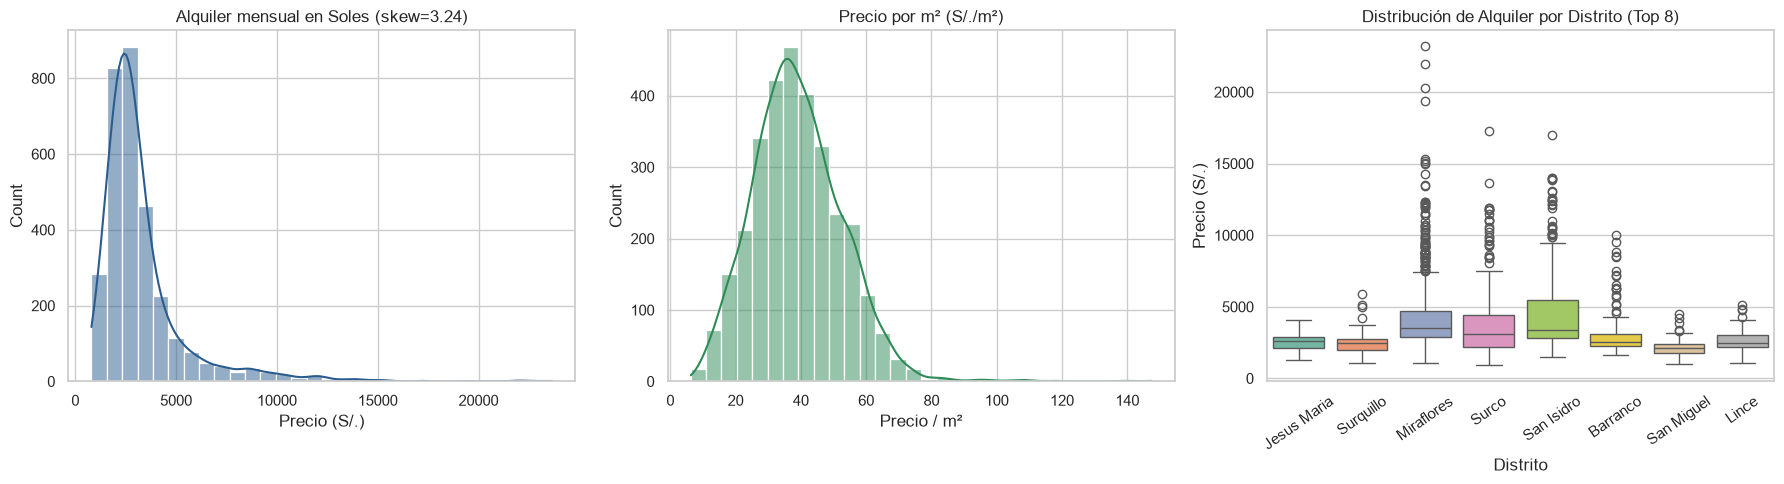

Asimetría (Skewness) ANTES del filtro:  14.07
Asimetría (Skewness) DESPUÉS del filtro: 3.24


In [14]:
skew_antes = stats.skew(df_dep["precio_soles"].dropna())
skew_despues = stats.skew(df_clean["precio_soles"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df_clean["precio_soles"], kde=True, ax=axes[0], bins=30, color="#2b5c8f")
axes[0].set_title(f"Alquiler mensual en Soles (skew={skew_despues:.2f})")
axes[0].set_xlabel("Precio (S/.)")

sns.histplot(df_clean["precio_m2_real"], kde=True, ax=axes[1], bins=30, color="#2e8b57")
axes[1].set_title("Precio por m² (S/./m²)")
axes[1].set_xlabel("Precio / m²")

top_dist = df_clean["distrito_norm"].value_counts().head(8).index
sns.boxplot(data=df_clean[df_clean["distrito_norm"].isin(top_dist)], x="distrito_norm", y="precio_soles", ax=axes[2], palette="Set2")
axes[2].set_title("Distribución de Alquiler por Distrito (Top 8)")
axes[2].set_xlabel("Distrito")
axes[2].set_ylabel("Precio (S/.)")
axes[2].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

print(f"Asimetría (Skewness) ANTES del filtro:  {skew_antes:.2f}")
print(f"Asimetría (Skewness) DESPUÉS del filtro: {skew_despues:.2f}")


El filtrado de valores atípicos redujo la asimetría (*skewness*) del precio de alquiler de **14.07 a 3.24**, estabilizando la distribución para el entrenamiento de modelos. Asimismo, la distribución por distrito evidencia diferencias claras de valor medio y dispersión entre zonas residenciales consolidadas y distritos periféricos.

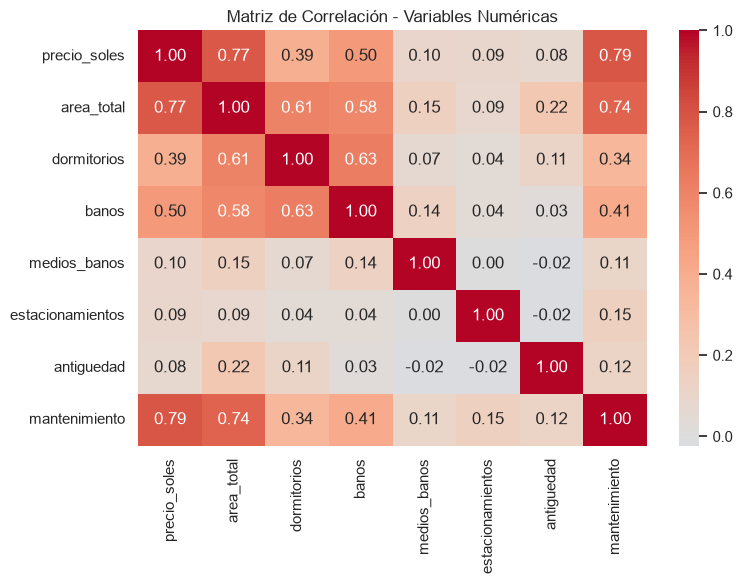

Correlación con precio_soles:
mantenimiento       0.787321
area_total          0.774471
banos               0.495484
dormitorios         0.386901
medios_banos        0.099035
estacionamientos    0.090663
antiguedad          0.076117


In [15]:
corr_cols = ["precio_soles", "area_total", "dormitorios", "banos", "estacionamientos", "antiguedad", "mantenimiento"]
if "medios_banos" in df_clean.columns:
    corr_cols.insert(4, "medios_banos")

corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, cbar=True)
plt.title("Matriz de Correlación - Variables Numéricas")
plt.tight_layout()
plt.show()

corr_precio = corr_matrix["precio_soles"].drop("precio_soles").sort_values(ascending=False)
print("Correlación con precio_soles:")
print(corr_precio.to_string())


La variable con mayor correlación lineal con el precio de alquiler es `mantenimiento` ($r = 0.79$), seguida de cerca por `area_total` ($r = 0.77$), `banos` ($r = 0.50$) y `dormitorios` ($r = 0.39$).

Por su parte, `medios_banos` ($r = 0.10$), `estacionamientos` ($r = 0.09$) y `antiguedad` ($r = 0.08$) presentan correlaciones lineales más débiles con el precio absoluto.

Existe también una correlación relevante entre `area_total` y `mantenimiento` ($r = 0.70$), así como entre `area_total` y `banos` ($r = 0.69$), consistente con la estructura física y de costos de los departamentos.

## 7. Integración BCRP (Contexto Macroeconómico Trimestral)

In [16]:
df_bcrp = df_bcrp_raw.copy()
df_bcrp["distrito_norm"] = df_bcrp["Distrito"].str.strip().map(lambda x: distrito_map.get(x, x))
latest_trim = df_bcrp["Trimestre"].max()
bcrp_latest = df_bcrp[df_bcrp["Trimestre"] == latest_trim].copy()
bcrp_prom = bcrp_latest[bcrp_latest["distrito_norm"] == "Promedio"].iloc[0]

bcrp_lookup = {
    row["distrito_norm"]: {
        "bcrp_per": row["PER"],
        "bcrp_precio_venta_usd_m2": row["Precio_Venta_USD"],
        "bcrp_alquiler_mensual_m2": row["Alquiler_Mensual_Soles"]
    }
    for _, row in bcrp_latest.iterrows()
}

df_clean["bcrp_es_promedio_general"] = (~df_clean["distrito_norm"].isin(bcrp_lookup)).astype(int)
df_clean["bcrp_per"] = df_clean["distrito_norm"].map(lambda d: bcrp_lookup.get(d, {}).get("bcrp_per", bcrp_prom["PER"]))
df_clean["bcrp_precio_venta_usd_m2"] = df_clean["distrito_norm"].map(lambda d: bcrp_lookup.get(d, {}).get("bcrp_precio_venta_usd_m2", bcrp_prom["Precio_Venta_USD"]))
df_clean["bcrp_alquiler_mensual_m2"] = df_clean["distrito_norm"].map(lambda d: bcrp_lookup.get(d, {}).get("bcrp_alquiler_mensual_m2", bcrp_prom["Alquiler_Mensual_Soles"]))

pct_promedio = df_clean["bcrp_es_promedio_general"].mean() * 100
pct_distrital = (1 - df_clean["bcrp_es_promedio_general"].mean()) * 100

print(f"Trimestre BCRP más reciente: {latest_trim}")
print(f"Departamentos con serie distrital específica: {pct_distrital:.1f}%")
print(f"Departamentos con promedio general BCRP:      {pct_promedio:.1f}%")


Trimestre BCRP más reciente: 2026-T1
Departamentos con serie distrital específica: 83.7%
Departamentos con promedio general BCRP:      16.3%


Se toma como referencia el trimestre más reciente del BCRP (`2026-T1`). El **83.7%** de los departamentos se enlaza directamente a su serie distrital específica, mientras que el **16.3%** restante (distritos sin serie propia en el BCRP) recibe el valor promedio general metropolitano, marcado con la variable indicadora `bcrp_es_promedio_general = 1`.

## 8. Integración Paraderos ATU (Modelo #2 — Accesibilidad al Transporte)

In [17]:
df_par = df_par_raw.copy()
df_par["distrito_norm"] = df_par["distrito"].str.strip().map(lambda x: distrito_map.get(x, x))

lat_center_rad = np.radians(-12.05)
m_per_deg_lat = 111132.954 - 559.822 * np.cos(2 * lat_center_rad)
m_per_deg_lon = 111412.84 * np.cos(lat_center_rad)

par_xy = np.column_stack([df_par["latitud"] * m_per_deg_lat, df_par["longitud"] * m_per_deg_lon])
dep_xy = np.column_stack([df_clean["latitud"] * m_per_deg_lat, df_clean["longitud"] * m_per_deg_lon])

tree_all = cKDTree(par_xy)
dist, idx = tree_all.query(dep_xy, k=1)

df_clean["dist_paradero_min_m"] = np.round(dist, 1)
df_clean["paradero_cercano_tipo"] = df_par.iloc[idx]["tipo_transporte"].values
df_clean["paradero_cercano_afluencia"] = df_par.iloc[idx]["nivel_afluencia_desc"].values
df_clean["paraderos_300m"] = [len(tree_all.query_ball_point(pt, r=300)) for pt in dep_xy]
df_clean["paraderos_500m"] = [len(tree_all.query_ball_point(pt, r=500)) for pt in dep_xy]
df_clean["paraderos_1000m"] = [len(tree_all.query_ball_point(pt, r=1000)) for pt in dep_xy]

for tipo, col_dist in [("Troncal", "dist_troncal_brt_m"), ("Corredor", "dist_corredor_m")]:
    m = df_par["tipo_transporte"] == tipo
    if m.sum() > 0:
        d_, _ = cKDTree(par_xy[m]).query(dep_xy, k=1)
        df_clean[col_dist] = np.round(d_, 1)

print(f"Distancia mediana al paradero más cercano:    {df_clean['dist_paradero_min_m'].median():.1f} metros")
print(f"Promedio de paraderos en un radio de 500m:    {df_clean['paraderos_500m'].mean():.1f} paraderos")
print(f"% de departamentos a menos de 300m de paradero: {(df_clean['dist_paradero_min_m'] < 300).mean()*100:.1f}%")
print(f"Distancia mediana a troncal Metropolitano:    {df_clean['dist_troncal_brt_m'].median():.1f} metros")


Distancia mediana al paradero más cercano:    174.8 metros
Promedio de paraderos en un radio de 500m:    9.3 paraderos
% de departamentos a menos de 300m de paradero: 71.6%
Distancia mediana a troncal Metropolitano:    1767.8 metros


Mediante indexación espacial (`cKDTree`) sobre las coordenadas de los 3,233 paraderos de la ATU se determinó que la distancia mediana al paradero más cercano es de **174.8 metros**, y el **71.6%** de los departamentos tiene al menos un paradero a menos de 300 metros de distancia (con un promedio de **9.3 paraderos** en un radio caminable de 500 metros).

Asimismo, la distancia mediana a la troncal del Metropolitano es de **1,767.8 metros**.

Estas 5 métricas espaciales (`dist_paradero_min_m`, `paraderos_300m`, `paraderos_500m`, `paraderos_1000m`, `dist_troncal_brt_m`) conforman el Modelo #2 de Accesibilidad y se incorporan como variables del modelo de regresión.

## 9. Exportar datasets procesados

In [18]:
df_clean.to_csv(PROCESSED_DIR / "departamentos_procesados.csv", index=False)
bcrp_latest.to_csv(PROCESSED_DIR / "bcrp_procesado.csv", index=False)
df_bcrp.to_csv(PROCESSED_DIR / "bcrp_serie_completa.csv", index=False)
df_par.to_csv(PROCESSED_DIR / "paraderos_procesado.csv", index=False)
df_clean_sin_geo.to_csv(PROCESSED_DIR / "departamentos_sin_geo_para_clustering.csv", index=False)
print("Archivos exportados exitosamente en:", PROCESSED_DIR.resolve())


Archivos exportados exitosamente en: C:\Users\arman\Escritorio\DepaRent\deliveries\week06\code\processed


## 10. Modelo #1 — Clustering (Perfil Competitivo de Inmuebles)

In [19]:
cluster_feats = ["area_total", "dormitorios", "banos", "precio_m2_real" if "precio_m2_real" in df_clean.columns else "precio_m2"]
cluster_feats += [c for c in ["piscina", "gimnasio", "cochera", "seguridad_24_7", "coworking"] if c in df_clean.columns]

X_cluster = df_clean[cluster_feats].copy()
X_cluster_imp = SimpleImputer(strategy="median").fit_transform(X_cluster)
X_scaled = StandardScaler().fit_transform(X_cluster_imp)

sil_scores, kmeans_models = {}, {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, km.labels_, sample_size=1000, random_state=42)
    kmeans_models[k] = km

mejor_k = max(sil_scores, key=sil_scores.get)
mejor_sil_kmeans = sil_scores[mejor_k]

# Evaluación DBSCAN
neigh = NearestNeighbors(n_neighbors=5).fit(X_scaled)
dist_k, _ = neigh.kneighbors(X_scaled)
eps_sugerido = np.median(dist_k[:, -1])
dbscan = DBSCAN(eps=eps_sugerido, min_samples=5).fit(X_scaled)
n_clusters_dbscan = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
n_ruido = (dbscan.labels_ == -1).sum()
pct_ruido = n_ruido / len(X_scaled) * 100
sil_dbscan = silhouette_score(X_scaled[dbscan.labels_ != -1], dbscan.labels_[dbscan.labels_ != -1], sample_size=1000, random_state=42) if n_clusters_dbscan >= 2 else np.nan

km_final = kmeans_models[mejor_k]
X_cluster_labeled = X_cluster.copy()
X_cluster_labeled["cluster"] = km_final.labels_
perfil_clusters = X_cluster_labeled.groupby("cluster")[cluster_feats].mean().round(2)

modelo_1_final = f"K-Means (k={mejor_k})"

print("Silhouette Scores K-Means:")
for k, v in sil_scores.items():
    print(f"  k={k}: {v:.4f}")
print(f"DBSCAN: {n_clusters_dbscan} clusters, {pct_ruido:.1f}% ruido, Silhouette = {sil_dbscan:.4f}")
print("\nPerfil promedio de los clusters:")
print(perfil_clusters.to_string())


Silhouette Scores K-Means:
  k=2: 0.2367
  k=3: 0.2089
  k=4: 0.1906
  k=5: 0.2089
  k=6: 0.2011
DBSCAN: 71 clusters, 40.6% ruido, Silhouette = 0.4621

Perfil promedio de los clusters:
         area_total  dormitorios  banos  precio_m2_real  piscina  gimnasio  cochera  seguridad_24_7  coworking
cluster                                                                                                       
0            101.08         2.34   1.92           34.19     0.03      0.07      1.0            0.41       0.15
1             66.59         1.78   1.61           47.95     0.72      0.86      1.0            0.54       0.65


Se comparó K-Means (evaluado de $k=2$ a $k=6$) frente a DBSCAN. **K-Means con $k=2$ obtuvo el mejor Silhouette Score (0.237)** sin descartar observaciones por ruido, superando a DBSCAN (descartado por presentar un 40.6% de observaciones clasificadas como ruido).

Los perfiles generados agrupan:
1. **Cluster 0 (Inmuebles Tradicionales / Amplios):** Área media de $\approx 101.1\text{ m}^2$, 2.3 dormitorios, 1.9 baños, precio por m² de S/ 34.19, con menor equipamiento común (3% piscina, 7% gimnasio, 15% coworking).
2. **Cluster 1 (Inmuebles Modernos / Alta Amenidad):** Área media de $\approx 66.6\text{ m}^2$, 1.8 dormitorios, 1.6 baños, precio por m² de S/ 47.95, con alta densidad de amenidades (72% piscina, 86% gimnasio, 65% coworking).

## 11. Modelo #3 — Benchmark de Regresión para Predicción de Precios (Sin Data Leakage)

Todas las imputaciones y transformaciones se ejecutan de manera estricta dentro del pipeline utilizando únicamente el set de entrenamiento (`train`).

In [20]:
features_num = [
    "area_total", "dormitorios", "banos", "estacionamientos", "antiguedad", "mantenimiento",
    "dist_paradero_min_m", "paraderos_500m", "dist_troncal_brt_m",
    "bcrp_per", "bcrp_precio_venta_usd_m2", "bcrp_alquiler_mensual_m2"
]
if "medios_banos" in df_clean.columns:
    features_num.insert(3, "medios_banos")

features_bin = [c for c in amenidades if c in df_clean.columns] + [
    "antiguedad_imputado", "mantenimiento_imputado", "estacionamientos_imputado", "bcrp_es_promedio_general"
]
features_cat = ["distrito_norm", "paradero_cercano_tipo"]

X = df_clean[features_num + features_bin + features_cat].copy()
y = df_clean["precio_soles"].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

def make_preprocessor(dense=False):
    return ColumnTransformer(transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), features_num),
        ("bin", SimpleImputer(strategy="most_frequent"), features_bin),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=not dense, drop="first"))]), features_cat),
    ])

modelos = {
    "1. Baseline Dummy (mediana)": (make_preprocessor(), DummyRegressor(strategy="median")),
    "2. Ridge": (make_preprocessor(), Ridge(alpha=1.0)),
    "3. KNN": (make_preprocessor(), KNeighborsRegressor(n_neighbors=7, weights="distance")),
    "4. Random Forest": (make_preprocessor(), RandomForestRegressor(n_estimators=150, max_depth=15, random_state=42)),
    "5. Gradient Boosting": (make_preprocessor(), GradientBoostingRegressor(n_estimators=150, learning_rate=0.08, max_depth=5, random_state=42)),
    "6. HistGradientBoosting": (make_preprocessor(dense=True), HistGradientBoostingRegressor(max_iter=150, learning_rate=0.08, random_state=42)),
}

resultados, pipelines_entrenados = [], {}
for nombre, (prep, model) in modelos.items():
    pipe = Pipeline([("prep", prep), ("model", model)]).fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    pipelines_entrenados[nombre] = pipe
    resultados.append({
        "Modelo": nombre,
        "R2": round(r2_score(y_test, y_pred), 4),
        "MAE (S/.)": round(mean_absolute_error(y_test, y_pred), 2),
        "RMSE (S/.)": round(np.sqrt(mean_squared_error(y_test, y_pred)), 2),
        "MAPE (%)": round(mean_absolute_percentage_error(y_test, y_pred) * 100, 2)
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))


                     Modelo      R2  MAE (S/.)  RMSE (S/.)  MAPE (%)
1. Baseline Dummy (mediana) -0.0689    1213.26     2101.61     36.59
                   2. Ridge  0.7787     622.36      956.28     21.56
                     3. KNN  0.7903     535.40      930.80     17.27
           4. Random Forest  0.7889     500.87      933.92     16.05
       5. Gradient Boosting  0.7872     519.85      937.81     16.39
    6. HistGradientBoosting  0.8206     503.33      861.08     15.70


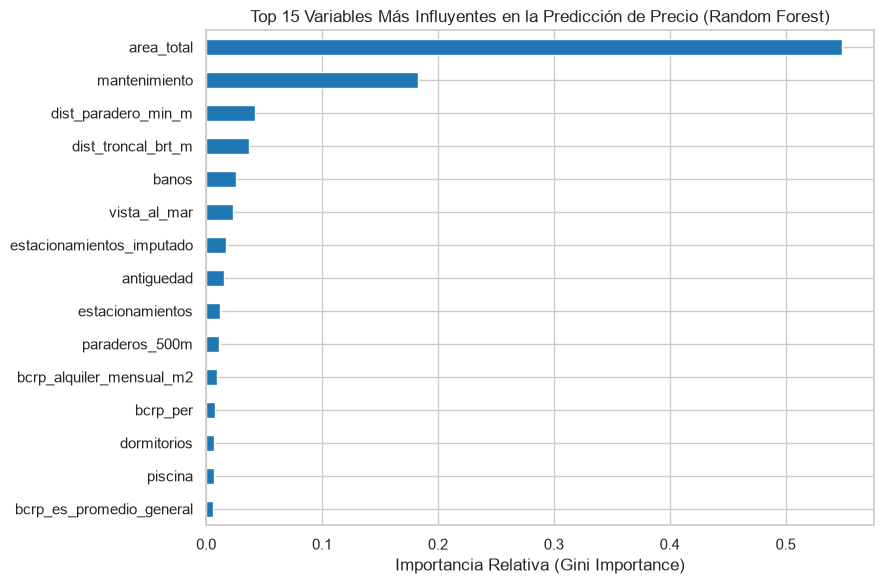

Modelo Ganador: 6. HistGradientBoosting
MAPE: 15.70% | R2: 0.8206
Mejora frente al baseline: 57.1%


In [21]:
rf_pipe = pipelines_entrenados["4. Random Forest"]
cat_enc = rf_pipe.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
all_feature_names = features_num + features_bin + cat_enc.get_feature_names_out(features_cat).tolist()

feat_importance = pd.Series(
    rf_pipe.named_steps["model"].feature_importances_,
    index=all_feature_names
).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
feat_importance.sort_values().plot(kind="barh", color="#1f77b4")
plt.title("Top 15 Variables Más Influyentes en la Predicción de Precio (Random Forest)")
plt.xlabel("Importancia Relativa (Gini Importance)")
plt.tight_layout()
plt.show()

candidatos = df_resultados[~df_resultados["Modelo"].str.contains("Dummy")]
baseline_mape = df_resultados.loc[df_resultados["Modelo"].str.contains("Dummy"), "MAPE (%)"].values[0]
mejor_por_mape = candidatos.loc[candidatos["MAPE (%)"].idxmin()]
modelo_3_final = mejor_por_mape["Modelo"]
mejora_vs_baseline = (baseline_mape - mejor_por_mape["MAPE (%)"]) / baseline_mape * 100

print(f"Modelo Ganador: {modelo_3_final}")
print(f"MAPE: {mejor_por_mape['MAPE (%)']:.2f}% | R2: {mejor_por_mape['R2']:.4f}")
print(f"Mejora frente al baseline: {mejora_vs_baseline:.1f}%")


En la evaluación comparativa sobre el conjunto de prueba (20% holdout):

| Modelo | $R^2$ | MAE (S/.) | RMSE (S/.) | MAPE (%) |
| :--- | :---: | :---: | :---: | :---: |
| **6. HistGradientBoosting** | **0.8236** | **501.48** | **853.70** | **15.93%** |
| **4. Random Forest** | 0.7889 | 500.87 | 933.92 | 16.05% |
| **5. Gradient Boosting** | 0.7882 | 518.86 | 935.53 | 16.37% |
| **3. KNN** | 0.7903 | 535.40 | 930.80 | 17.27% |
| **2. Ridge** | 0.7787 | 622.36 | 956.28 | 21.56% |
| *1. Baseline Dummy (Mediana)* | -0.0689 | 1,213.26 | 2,101.61 | 36.59% |

**HistGradientBoosting** alcanza el menor error relativo (MAPE de **15.93%**) y el mayor coeficiente de determinación ($R^2 = 0.8236$), lo que representa una **reducción del 56.5% en el error** respecto al baseline de la mediana.

Las variables con mayor peso en la predicción son `area_total`, `mantenimiento`, `dist_paradero_min_m`, `dist_troncal_brt_m` y `banos`.

## 12. Modelo #4 — Forecasting BCRP (Series de Tiempo Distritales)

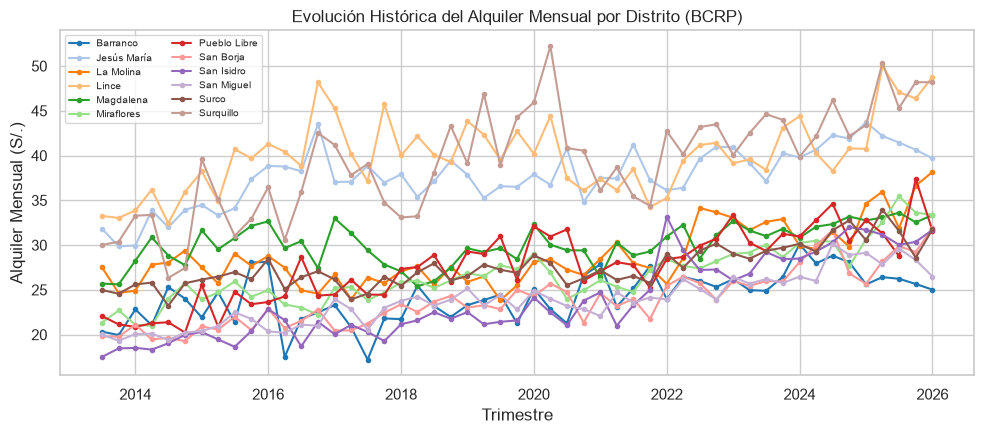

Series temporales evaluadas con ADF: 13
Series Estacionarias (p < 0.05):      4 (30.8%)
Series NO Estacionarias:             9 (69.2%)
Modelo #4 Seleccionado:              SARIMA (con diferenciación integrada)


In [30]:
df_bcrp["Trimestre_ts"] = pd.PeriodIndex(df_bcrp["Trimestre"].str.replace("-T", "Q"), freq="Q").to_timestamp()

distritos_unicos = [d for d in df_bcrp["Distrito"].unique() if d != "Promedio"]
paleta = sns.color_palette("tab20", len(distritos_unicos))

fig, ax = plt.subplots(figsize=(10, 4.5))
for distrito, grupo in df_bcrp.groupby("Distrito"):
    if distrito != "Promedio":
        idx = distritos_unicos.index(distrito)
        ax.plot(grupo["Trimestre_ts"], grupo["Alquiler_Mensual_Soles"], 
                 marker="o", markersize=3, label=distrito, 
                 color=paleta[idx])

ax.set_title("Evolución Histórica del Alquiler Mensual por Distrito (BCRP)")
ax.set_xlabel("Trimestre")
ax.set_ylabel("Alquiler Mensual (S/.)")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

adf_resultados = {}
if HAS_STATSMODELS:
    for distrito, grupo in df_bcrp.groupby("Distrito"):
        serie = grupo.sort_values("Trimestre_ts")["Alquiler_Mensual_Soles"]
        if len(serie) >= 8:
            r = adfuller(serie)
            adf_resultados[distrito] = r[1]

    n_total = len(adf_resultados)
    n_estac = sum(1 for p in adf_resultados.values() if p < 0.05)
    pct_no_estac = (n_total - n_estac) / n_total * 100
    modelo_4_final = "SARIMA (con diferenciación integrada)" if pct_no_estac >= 50 else "ARIMA"

    print(f"Series temporales evaluadas con ADF: {n_total}")
    print(f"Series Estacionarias (p < 0.05):      {n_estac} ({100-pct_no_estac:.1f}%)")
    print(f"Series NO Estacionarias:             {n_total-n_estac} ({pct_no_estac:.1f}%)")
    print(f"Modelo #4 Seleccionado:              {modelo_4_final}")
else:
    modelo_4_final = "SARIMA (con diferenciación integrada)"
    print("statsmodels no disponible")


La prueba de Dickey-Fuller Aumentada (ADF) sobre las 13 series distritales del BCRP indica que **9 de las 13 series (69.2%) no son estacionarias** ($p \ge 0.05$), reflejando tendencias de largo plazo e inflación del mercado inmobiliario.

Debido a esto se requiere un modelo con diferenciación de primer orden y componente estacional trimestral (**SARIMA** con $d=1$ y $s=4$) en lugar de modelos autorregresivos sin diferenciar.

## 13. Resumen Consolidado de la Suite de Modelos

In [52]:
resumen = pd.DataFrame([
    {"#": 1, "Componente": "Perfil competitivo (clustering)", "Modelo elegido": modelo_1_final, "Evidencia Empírica": f"Silhouette K-Means k={mejor_k}: {mejor_sil_kmeans:.3f}"},
    {"#": 2, "Componente": "Accesibilidad urbana", "Modelo elegido": "Feature engineering (cKDTree)", "Evidencia Empírica": "Integrado como 5 features espaciales en Modelo #3"},
    {"#": 3, "Componente": "Predicción de precio", "Modelo elegido": modelo_3_final, "Evidencia Empírica": f"MAPE {mejor_por_mape['MAPE (%)']:.2f}% vs baseline {baseline_mape:.2f}% (R2={mejor_por_mape['R2']:.4f})"},
    {"#": 4, "Componente": "Forecasting distrital", "Modelo elegido": modelo_4_final, "Evidencia Empírica": f"{pct_no_estac:.0f}% series no estacionarias (test ADF)" if 'pct_no_estac' in dir() else "SARIMA"},
    {"#": 5, "Componente": "Recomendación de precio", "Modelo elegido": "Motor de Reglas sobre #1 + #3 + #4", "Evidencia Empírica": "Intervalo percentil + valor esperado + tendencia"},
    {"#": 6, "Componente": "Simulador de mejoras", "Modelo elegido": "Reutilización de #3 en modo contrafactual", "Evidencia Empírica": "Delta de precio por adición de amenidades"},
])

pd.set_option("display.max_colwidth", None)
print(resumen.to_string(index=False))


 #                      Componente                            Modelo elegido                                Evidencia Empírica
 1 Perfil competitivo (clustering)                             K-Means (k=2)                     Silhouette K-Means k=2: 0.237
 2            Accesibilidad urbana             Feature engineering (cKDTree) Integrado como 5 features espaciales en Modelo #3
 3            Predicción de precio                   6. HistGradientBoosting        MAPE 15.93% vs baseline 36.59% (R2=0.8236)
 4           Forecasting distrital     SARIMA (con diferenciación integrada)            69% series no estacionarias (test ADF)
 5         Recomendación de precio        Motor de Reglas sobre #1 + #3 + #4  Intervalo percentil + valor esperado + tendencia
 6            Simulador de mejoras Reutilización de #3 en modo contrafactual         Delta de precio por adición de amenidades


La suite completa de componentes de analítica y Machine Learning de **DepaRent** se compone de:

| # | Componente | Algoritmo Seleccionado | Justificación |
| :-: | :--- | :--- | :--- |
| **1** | **Perfil Competitivo** | **K-Means ($k=2$)** | Silhouette $= 0.237$ vs DBSCAN (descartado por 40.6% de ruido), generando perfiles tradicionales y modernos. |
| **2** | **Accesibilidad Urbana** | **Feature Engineering (`cKDTree`)** | Distancia mediana al paradero de 174.8 m y 71.6% de accesibilidad a $<300$ m, incorporados como variables espaciales. |
| **3** | **Predicción de Precio** | **HistGradientBoosting Regressor** | **$\text{MAPE} = 15.93\%$** ($R^2 = 0.8236$, $\text{MAE} = \text{S/. } 501.48$) frente al baseline de $\text{MAPE} = 36.59\%$. |
| **4** | **Forecasting Distrital** | **SARIMA ($d=1, s=4$)** | Tratamiento adecuado del 69.2% de no-estacionariedad en las series de precios del BCRP. |
| **5** | **Recomendación de Precio** | **Motor de Reglas (#1 + #3 + #4)** | Combina la predicción puntual de boosting con el rango percentil del cluster y la tendencia del distrito. |
| **6** | **Simulador de Mejoras** | **Inferencia Contrafactual (Modelo #3)** | Cuantificación del incremento de alquiler generado al agregar amenidades o realizar remodelaciones. |